# Heart Disease Prediction using XGBoost: Complete ML Pipeline

## Objective

Build an end-to-end machine learning pipeline for predicting whether a patient has a history of heart disease or heart attack.

Workflow:

1. Data Understanding
2. Data Cleaning
3. Missing Value Analysis
4. Exploratory Data Analysis
5. Correlation Analysis
6. Train/Test Split
7. XGBoost Training
8. Model Evaluation
9. Feature Importance
10. Save Model

Target Variable:

HeartDiseaseorAttack

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import os
from xgboost import XGBClassifier

import joblib

## 2. Load Dataset

In [4]:
Data_Path = os.path.join(os.getcwd(), 'Data/heart_disease', 'heart_disease.csv')
df = pd.read_csv(Data_Path)

print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (253680, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
Diabetes,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


# Missing Value Analysis
Check if dataset contains missing values.

In [7]:
missing=df.isnull().sum()

missing=missing[missing>0]

if len(missing)>0:

    plt.figure(figsize=(12,5))

    missing.sort_values().plot(
        kind='bar'
    )

    plt.xticks(rotation=90)

    plt.show()

else:

    print("No missing values found")

No missing values found


# Target Distribution
Check class balance

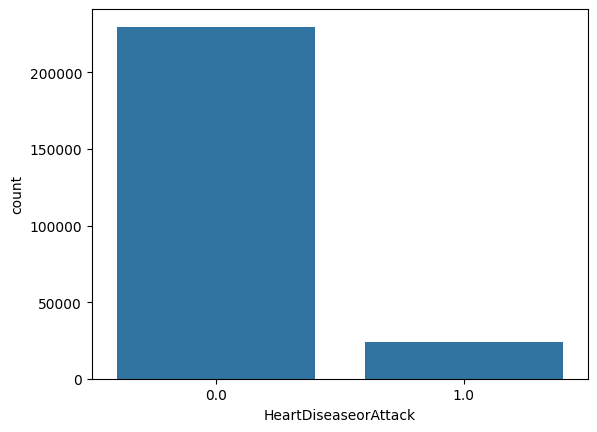

HeartDiseaseorAttack
0.0    90.581441
1.0     9.418559
Name: proportion, dtype: float64


In [8]:
sns.countplot(
    data=df,
    x='HeartDiseaseorAttack'
)

plt.show()

print(
df['HeartDiseaseorAttack']
.value_counts(normalize=True)*100
)

In [9]:
numerical=df.columns.drop(
'HeartDiseaseorAttack'
)

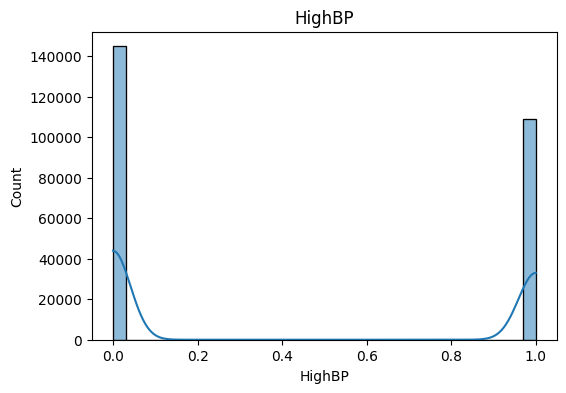

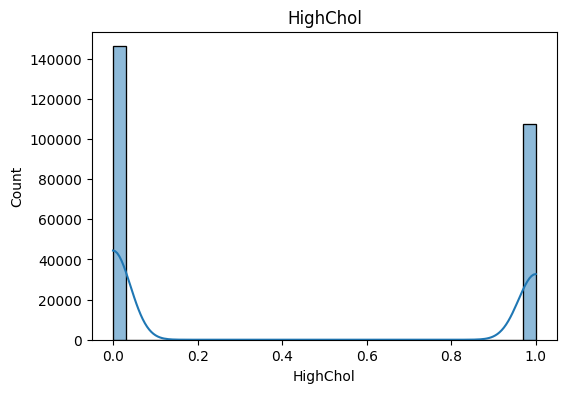

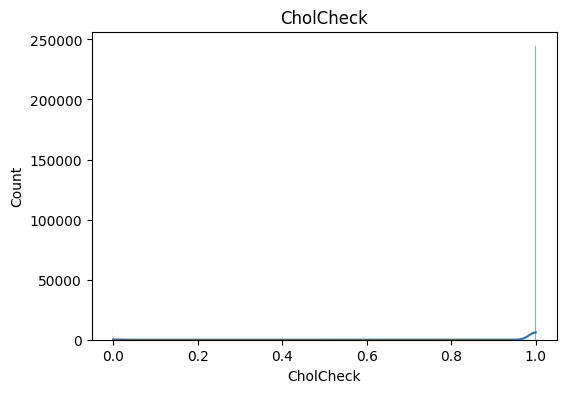

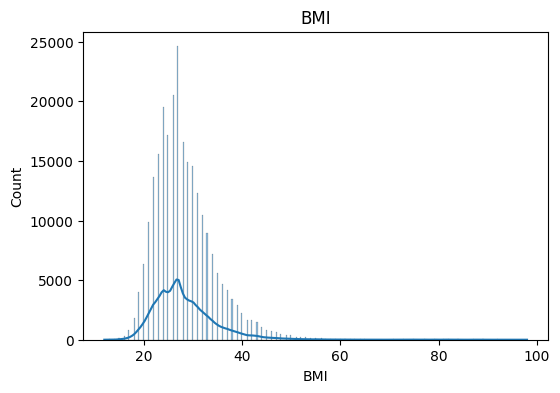

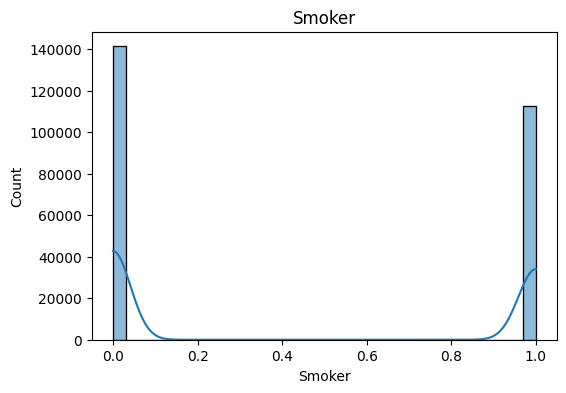

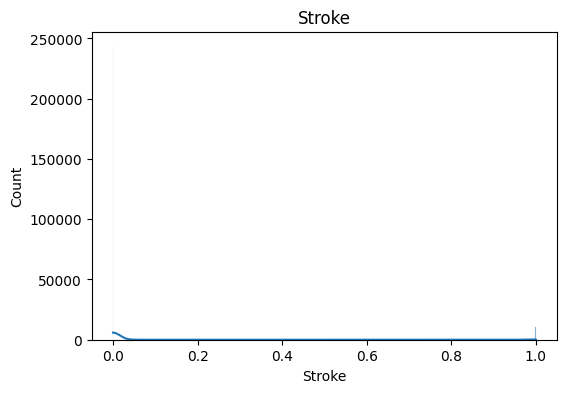

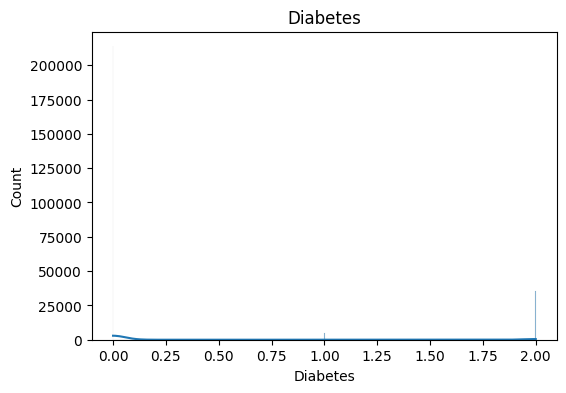

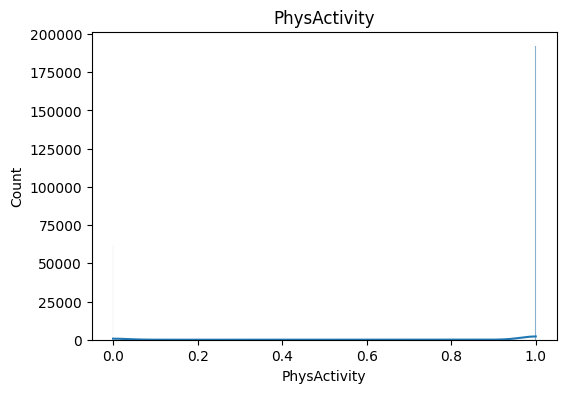

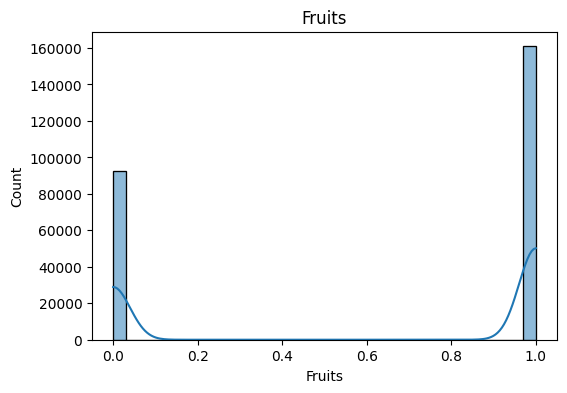

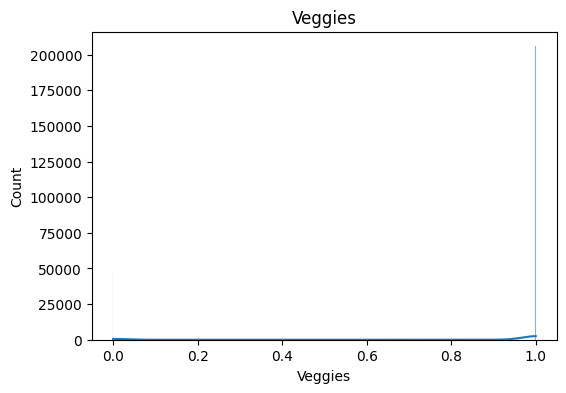

In [10]:
for col in numerical[:10]:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

# Correlation Heatmap
Identify relationships between features.

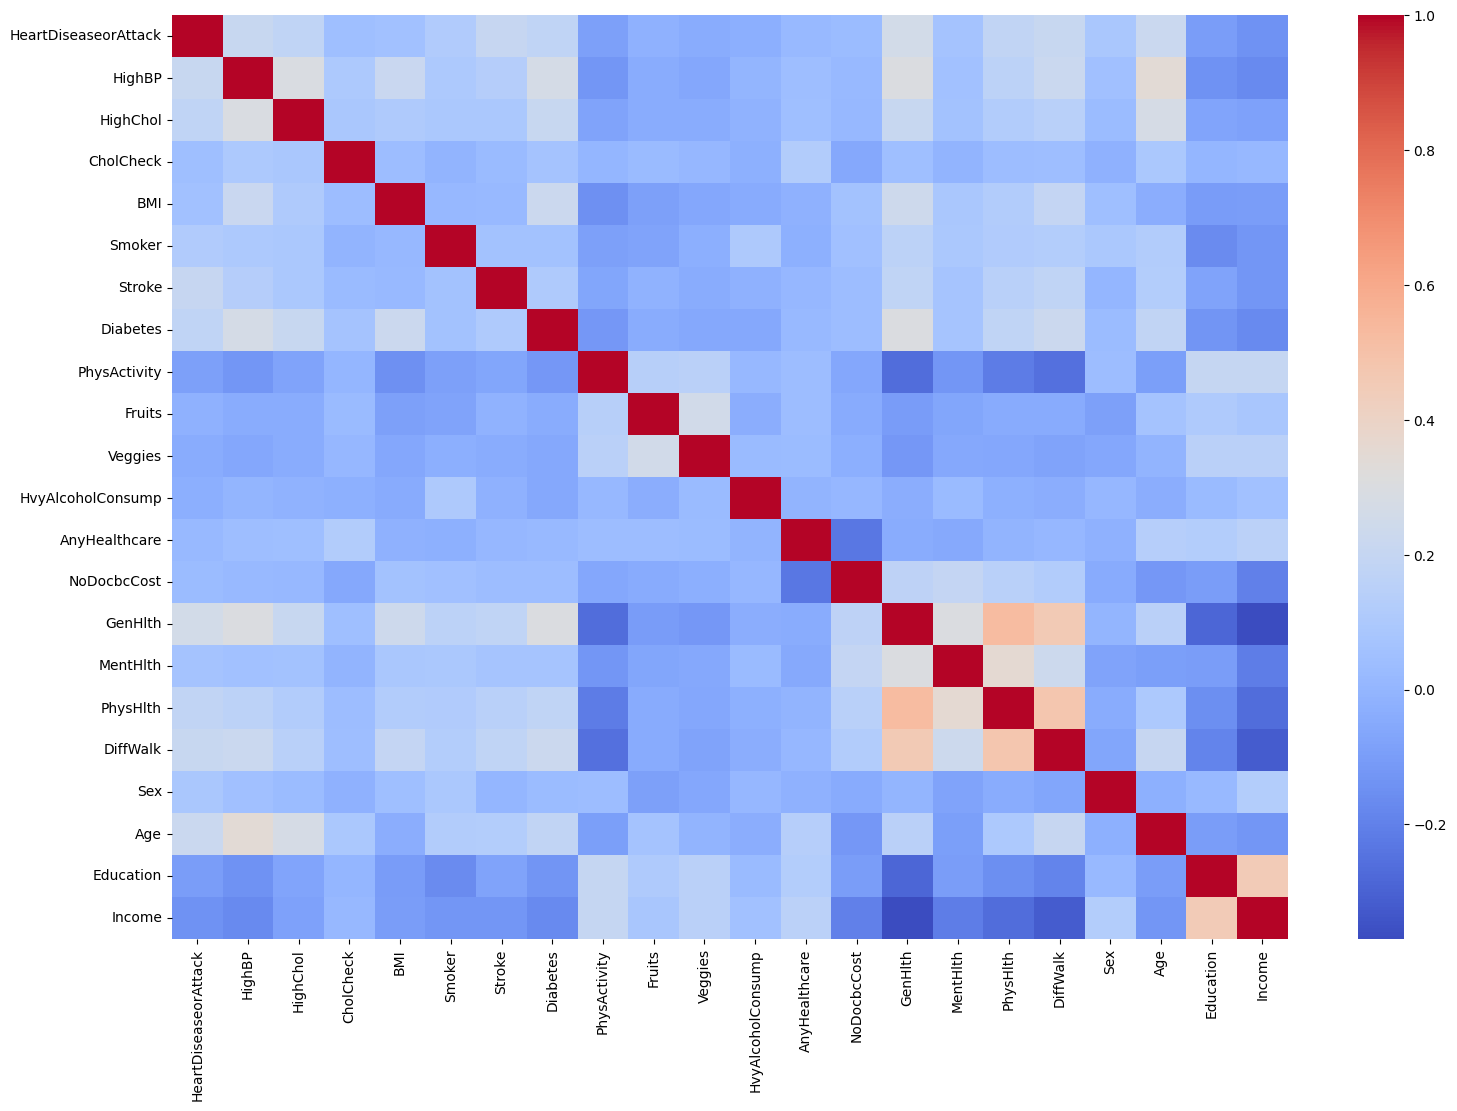

In [11]:
plt.figure(
    figsize=(18,12)
)

corr=df.corr()

sns.heatmap(
corr,
cmap='coolwarm'
)

plt.show()

# Important Feature vs Target

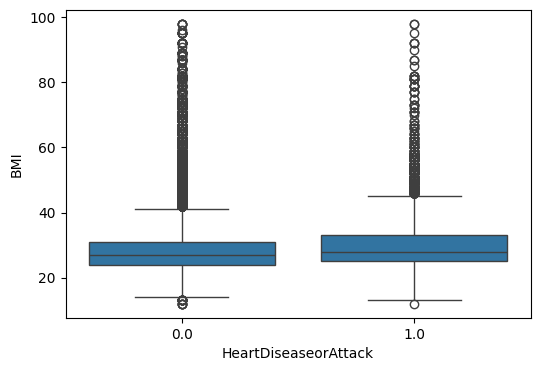

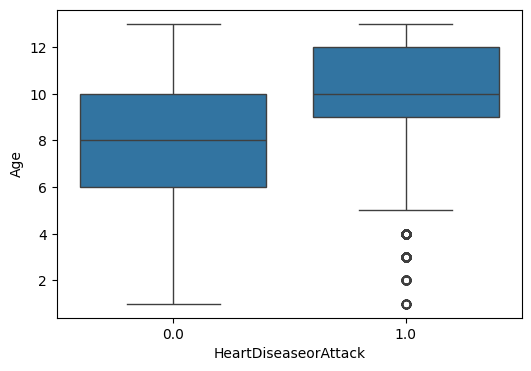

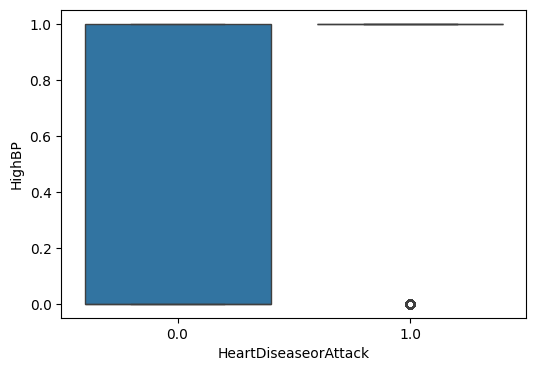

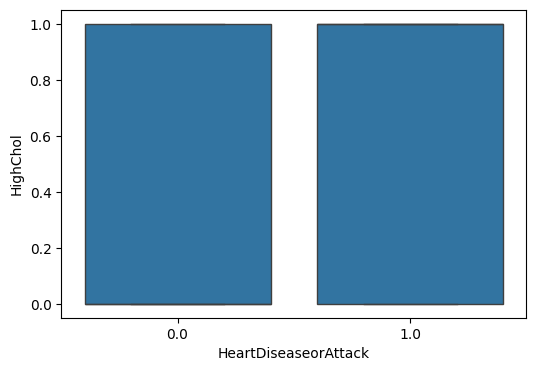

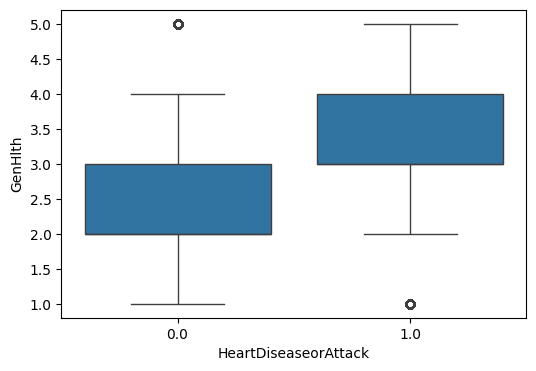

In [12]:
important=[

'BMI',
'Age',
'HighBP',
'HighChol',
'GenHlth'

]

for col in important:

    plt.figure(figsize=(6,4))

    sns.boxplot(
    data=df,
    x='HeartDiseaseorAttack',
    y=col
    )

    plt.show()

In [13]:
X=df.drop(
'HeartDiseaseorAttack',
axis=1
)

y=df[
'HeartDiseaseorAttack'
]

In [14]:
X_train,X_test,y_train,y_test= train_test_split(

X,
y,

test_size=.2,

random_state=42,

stratify=y

)

# Train XGBoost

In [15]:
model=XGBClassifier(

n_estimators=300,

learning_rate=.05,

max_depth=6,

subsample=.8,

colsample_bytree=.8,

random_state=42,

eval_metric='logloss'

)

In [16]:
model.fit(
X_train,
y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [17]:
pred=model.predict(
X_test
)

prob=model.predict_proba(
X_test
)[:,1]

In [18]:
"Accuracy:",
accuracy_score(
y_test,
pred
)

print(
classification_report(
y_test,
pred
)
)

              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95     45957
         1.0       0.54      0.11      0.18      4779

    accuracy                           0.91     50736
   macro avg       0.73      0.55      0.56     50736
weighted avg       0.88      0.91      0.88     50736



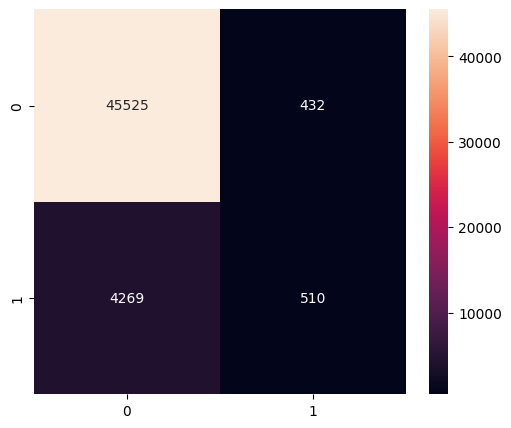

In [19]:
cm=confusion_matrix(
y_test,
pred
)

plt.figure(
figsize=(6,5)
)

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.show()

ROC AUC: 0.8499056836898806


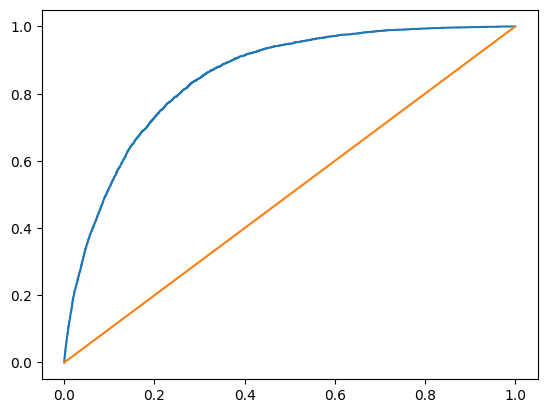

In [20]:
auc=roc_auc_score(
y_test,
prob
)

print(
"ROC AUC:",
auc
)

fpr,tpr,_=roc_curve(
y_test,
prob
)

plt.figure()

plt.plot(
fpr,
tpr
)

plt.plot(
[0,1],
[0,1]
)

plt.show()

In [21]:
importance=pd.DataFrame({

'Feature':X.columns,

'Importance':
model.feature_importances_

})

importance=importance.sort_values(
'Importance',
ascending=False
)

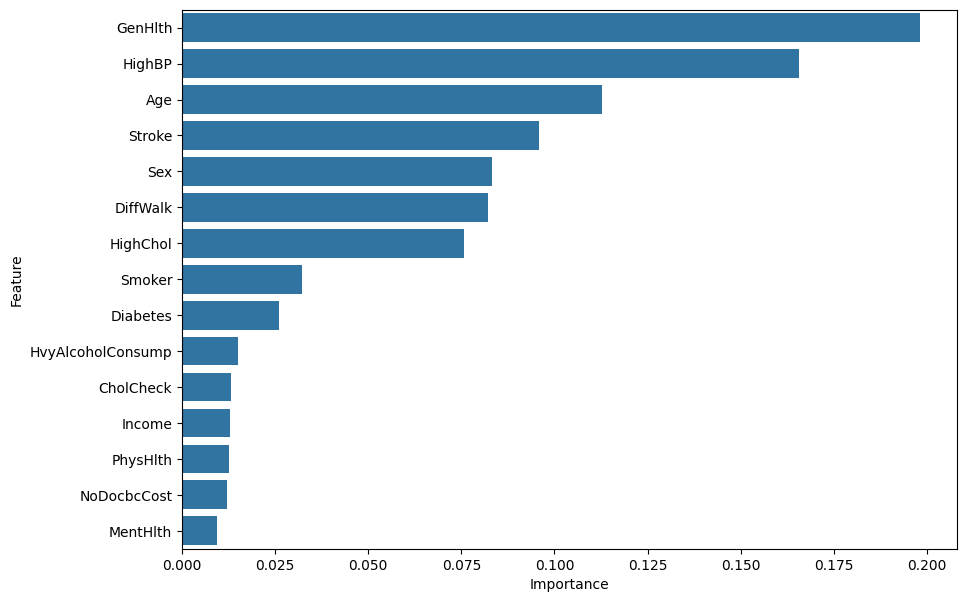

In [22]:
plt.figure(
figsize=(10,7)
)

sns.barplot(
data=importance.head(15),
x='Importance',
y='Feature'
)

plt.show()

In [23]:
joblib.dump(
model,
"Models/heart_xgboost.pkl"
)

print(
"Model Saved"
)

Model Saved
